In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone as fo

## list all dataset
print(fo.list_datasets())

# Close any zombie sessions that might be hanging
fo.close_app()

['dugong']


In [3]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import json
from fiftyone import ViewField as F
import matplotlib.pyplot as plt
import numpy as np


## renders plotly properly in a html instance. 
import plotly.io as pio
pio.renderers.default = "notebook"

# Meeting 19-05 

- Results from seed0, seed63, seed72.
- Evaluating zero-shot without domain adaptation.

## Variance of the three test set

Considering each independent West Papua flight mission, what is the expected variance to exist within the dataset? In other others, picking different MAN flights as test set, what is the underline variance expected?

In [4]:
# load dataset
dataset = fo.load_dataset("dugong")

## load views
nc_view = dataset.load_saved_view('nc')
wp_view = dataset.load_saved_view('wp')

## load saved test view
test_view_seed0 = dataset.load_saved_view('wp_test_s0')
test_view_seed63 = dataset.load_saved_view('wp_test_s63')
test_view_seed72 = dataset.load_saved_view('wp_test_s72')

In [5]:
# test view 0 flights
test_view_seed0.distinct('stratify_key')

['WP_FRIWEN_FRIWEN_M12', 'WP_FRIWEN_FRIWEN_M53', 'WP_MANTASANDY_MANTASANDY_M5']

In [6]:
# test view 63 flights 
test_view_seed63.distinct('stratify_key')

['WP_FRIWEN_FRIWEN_M19',
 'WP_FRIWEN_FRIWEN_M8',
 'WP_GAM_GAM_M10',
 'WP_MANTASANDY_MANTASANDY_M5',
 'WP_UM_UM_M1']

In [7]:
# test view 72 flights 
test_view_seed72.distinct('stratify_key')

['WP_MANTASANDY_MANTASANDY_M5', 'WP_UM_UM_M2', 'WP_UM_UM_M3', 'WP_UM_UM_M6']

How to evaluate it? 

Simple, each seed, also contains a slightly pre-trained model on New Caledonia. Therefore, if we infer a zero-shot of these three pre-trained models over the three different test sets, we can understand the underlying variance of the test set. 


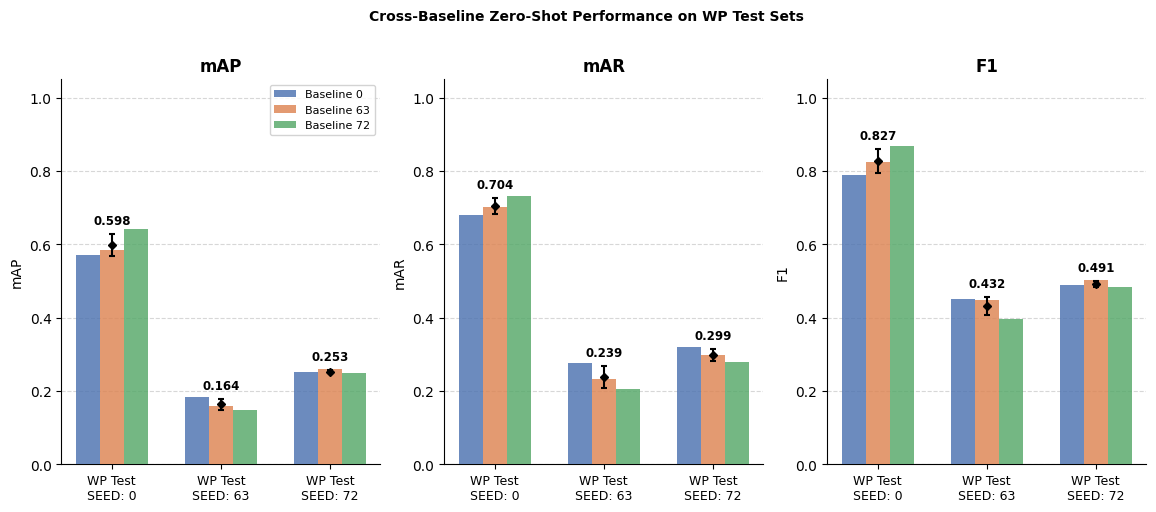

For the test set, we can draw:
- Seed 0 is the 'easiest'. Seed 63 the hardest, whereas seed 72 appears on a 'medium' landscape. 


So... what if we evaluate these test set according the Local Intrisinc Dimension and Optimal Transport?

What are we expecting from it? 

- At first glimpse, I would think that Seed 63 has the higher LID and the farthest distribution compared to NC.


-


-

Well...

## Estimating LID and Wasserstein distance on different the test set

Local Intrisic Dimension Estimation of the test set

| Seed   | k=20   | k=25   | k=30   |u +- std | 
| ------ | ------ | ------ | ------ | -----   |
| seed0  | 4.5153 | 4.1316 | 3.8508 | 4.17 +- 0.27 |
| seed63 | 4.2140 | 4.0013 | 3.9026 | 4.03 +- 0.13 |
| seed72 | 4.7119 | 4.1739 | 3.9537 | 4.27 +- 0.32 |



- Surprisingly, seed63 has the lower LID. 
- The 'easiest' seed test has a higher LID than seed63, even though the mAP, mAR metrics are way more discrepants.
- The difference of each seed regarding the LID may not seen statistically relevant.

Wasserstein Distance from NC

Here I randomly took the full NC (700 samples)  in NC and computed the wasserstein distance regarding the test set (100 samples)

| Test    | Wasserstein Distance |
| ------- | -------------------- |
| test_0  | 0.489119             |
| test_63 | 0.389137             |
| test_72 | 0.513352             |


- Again, surprisingly seed63 has the smaller distance in distribution when it comes to the NC distribution but at zero-shot is the hardest scenario to test it. 

--- 

SEED63 is the hardest WP test set for the NC model, yet it has:

The lowest LID (most geometrically homogeneous)
The smallest Wasserstein distance from NC (closest to NC in embedding space)

If difficulty were purely a function of distribution distance, SEED63 should be the easiest, not the hardest. But it is the hardest by a wide margin.

---

### Summary table

| Test Set | Zero-shot mAP | LID (k=25) | Wasserstein dist from NC | Dominant background |
|---|---|---|---|---|
| SEED0 | 0.57–0.64 (easy) | 4.17 (diverse) | 0.489 (medium) | Open water, low clutter |
| SEED63 | 0.15–0.18 (hard) | 4.03 (homogeneous) | 0.389 (closest to NC!) | Coral/algae, high clutter |
| SEED72 | 0.25 (medium) | 4.27 | 0.513 (furthest from NC) | Mixed |

The question is, why?

Some hypothesis:

1 — LID measures geometric complexity of the WP set itself, not its distance from NC.
Assuming that LID ≈ distance from NC manifold is not properly. LID is more a purely intrinsic property of the WP test set, measuring how many effective dimensions the data occupies locally, regardless of where NC sits in feature space.

Thus, a high LID WP set (SEED0, LID=4.17) means the WP images are more diverse - spanning a wider variety of visual conditions, backgrounds, dugong sizes, angles. A lower LID WP set (SEED63, 4.03) means the images are more clustered, more homogeneous.

2 — So think about homogeinity of images, a more homogeneous WP test set can be harder, not easier.
If SEED63's WP test partition happened to sample a narrow but very non-NC-like region of image space (e.g. all images from one specific lagoon with unusual water colour), it would have low LID (images are similar to each other) but high difficulty for the NC model (the entire cluster is far from NC). The NC model has never seen anything like it, and the images don't provide enough visual variation for the model to accidentally generalise.

Conversely, SEED0's high-LID partition samples diverse WP images, some of those diverse images are likely to resemble NC conditions, giving the NC model something to latch onto.

3 -  Even if the embedding distribution is close to NC (small Wasserstein distance), the visual discriminability of the object is fundamental for Object Detection tasks. 

This would explain why the Wasserstein distance misleads: the SEED63 embeddings are close to NC in the global feature space, but the locally discriminative features that distinguish dugong from background are completely different. The model arrives at a familiar-looking embedding space but the classification boundary is in the wrong place for coral backgrounds.



### Observing the set of images

Therefore, we need to look into these images representing each partition:

In open water images (SEED0):

Dugong body creates high contrast against uniform blue/green background
The object boundary is clean and well-defined
NC training data likely contains similar open water conditions
Detection is essentially a foreground-background separation problem — relatively simple

In coral/algae images (SEED63):

Dugong body blends into the brownish, textured substrate
The object boundary is ambiguous — similar colour and texture to background
Even if the embedding distribution is close to NC (small Wasserstein distance), the visual discriminability of the object is fundamentally lower
Detection requires understanding fine-grained texture differences, not just foreground-background separation

In [8]:
import matplotlib.image as mpimg


def plot_image_grid(
    image_paths: np.ndarray,
    dataset: fo.Dataset,
    title_field: str = "stratify_key",
    suptitle: str = "Selected Candidates by Uniqueness",
    n_cols: int = 4,
    max_images: int = 20,
    figsize_per_cell: tuple = (3.5, 3.5),
):
    """
    Plot a grid of images with metadata titles from a FiftyOne dataset.

    Args:
        image_paths   : array of absolute image paths (from wp_train_ids[selected_candidates])
        dataset       : FiftyOne dataset to look up metadata fields
        title_field   : sample field to use as subplot title (e.g. "stratify_key", "sea_state")
        suptitle      : overall figure title
        n_cols        : number of columns in the grid
        max_images    : maximum number of images to display
        figsize_per_cell : (w, h) in inches per cell
    """
    paths = image_paths[:max_images]
    n = len(paths)
    n_rows = int(np.ceil(n / n_cols))

    fig_w = figsize_per_cell[0] * n_cols
    fig_h = figsize_per_cell[1] * n_rows + 0.8  # extra space for suptitle

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = axes.flatten()

    for ax_idx, img_path in enumerate(paths):
        ax = axes[ax_idx]

        # ── load and display image ────────────────────────────────────────
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=7, color="red")

        ax.axis("off")

        # ── fetch title from FiftyOne dataset ─────────────────────────────
        try:
            sample = dataset[img_path]
            field_val = sample.get_field(title_field)
            title = str(field_val) if field_val is not None else Path(img_path).stem[:30]
        except Exception:
            # fallback: use filename stem
            title = Path(img_path).stem[:30]

        ax.set_title(title, fontsize=8, pad=3, wrap=True)

    # ── hide unused axes ──────────────────────────────────────────────────
    for ax_idx in range(n, len(axes)):
        axes[ax_idx].axis("off")

    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return fig

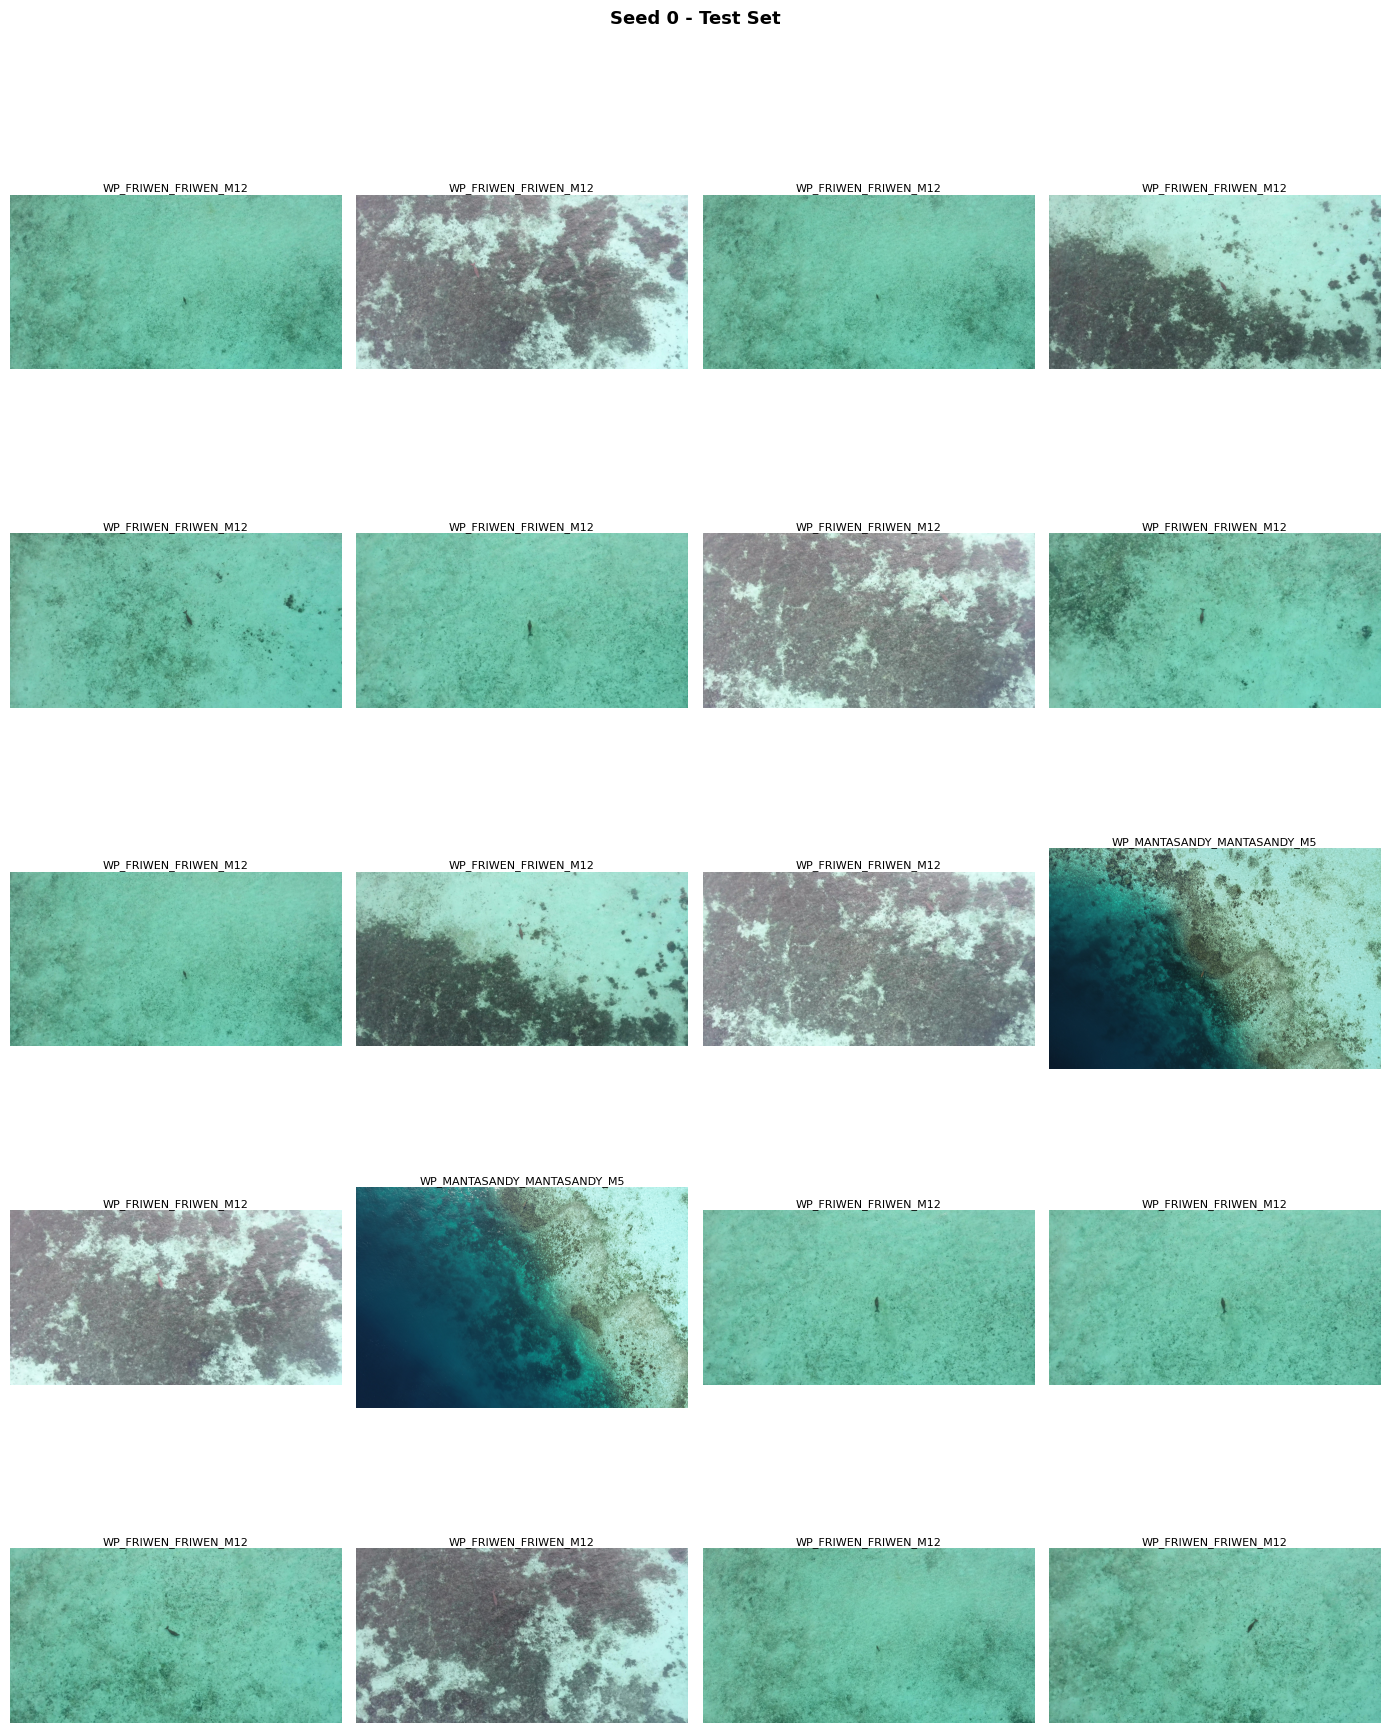

In [ ]:
fig = plot_image_grid(
    image_paths=test_view_seed0.take(20).values('filepath'),
    dataset=dataset,          # your FiftyOne dataset object
    title_field="stratify_key",
    suptitle="Seed 0 - Test Set",
    n_cols=4,
    max_images=20,
)

# optionally save
#fig.savefig("uniqueness_candidates.png", dpi=150, bbox_inches="tight")

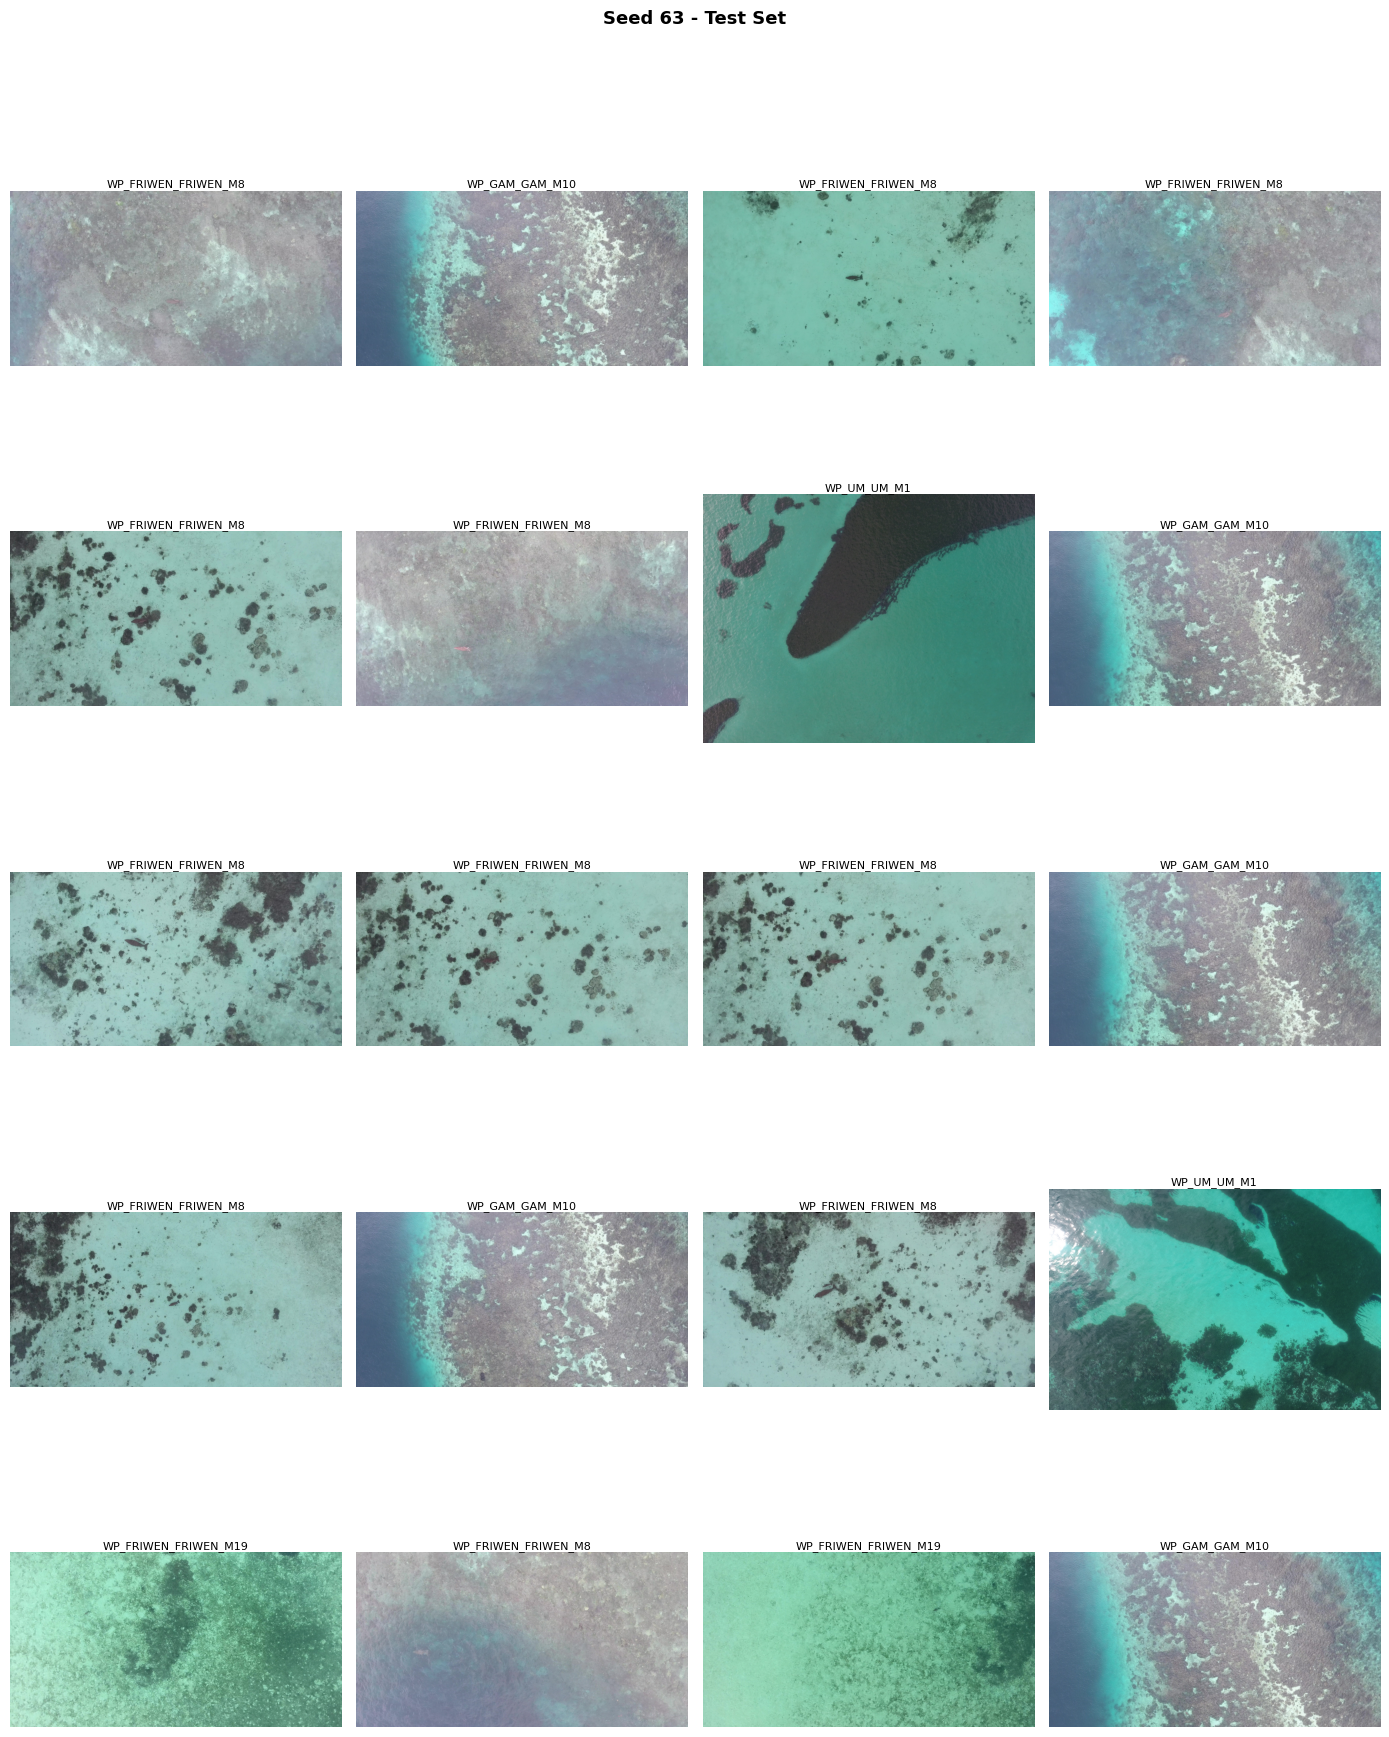

In [13]:
#
fig = plot_image_grid(
    image_paths=test_view_seed63.take(20).values('filepath'),
    dataset=dataset,          # your FiftyOne dataset object
    title_field="stratify_key",
    suptitle="Seed 63 - Test Set",
    n_cols=4,
    max_images=20,
)

# optionally save
#fig.savefig("uniqueness_candidates.png", dpi=150, bbox_inches="tight")

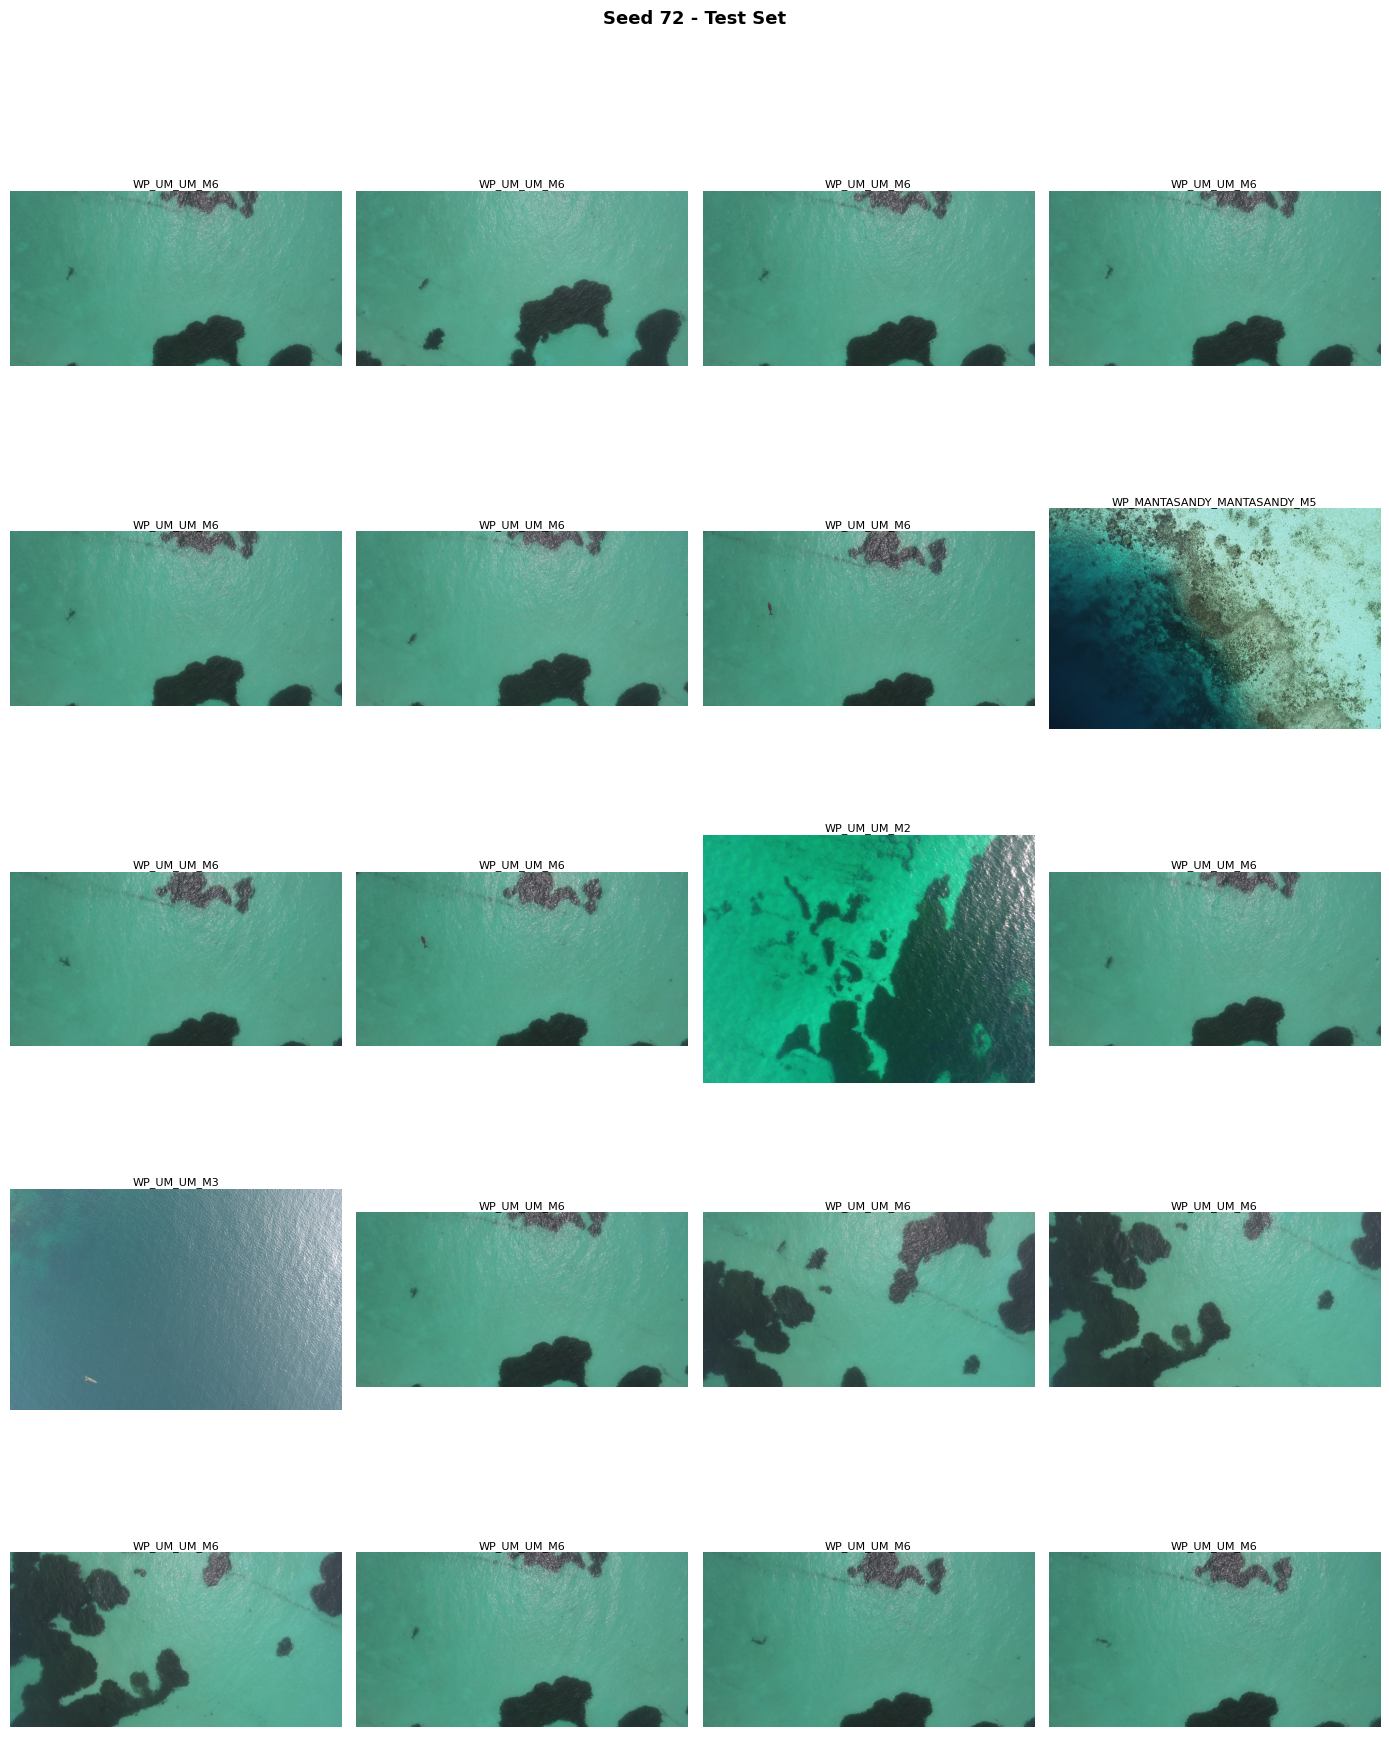

In [14]:
#
fig = plot_image_grid(
    image_paths=test_view_seed72.take(20).values('filepath'),
    dataset=dataset,          # your FiftyOne dataset object
    title_field="stratify_key",
    suptitle="Seed 72 - Test Set",
    n_cols=4,
    max_images=20,
)

# optionally save
#fig.savefig("uniqueness_candidates.png", dpi=150, bbox_inches="tight")

domain adaptation for object detection has two orthogonal axes of difficulty:
 - Axis 1 — Global distribution shift (measured by Wasserstein distance, LID)

        How different is the overall image distribution from NC? 

- Axis 2 — Ecological discriminability

        How visually separable is the object from its background in the target domain? 
        This is independent of distribution shift! You can have images that are close to NC globally but where the object is much harder to isolate due to background texture, colour similarity, or camouflage.

# Evaluating all seeds

In [51]:
# import df 
import pandas as pd 
import numpy as np 
df_seed0_results = pd.read_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation/evaluation_all_runs_seed0.csv')
df_seed63_results = pd.read_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation/evaluation_all_runs_seed63.csv')
df_seed72_results = pd.read_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation/evaluation_all_runs_seed72.csv')

df_baseline = pd.read_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/baseline_compare_testseeds.csv')

In [52]:
df_seed72_results

,Unnamed: 0,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,72,ACLR_p75_SEED72_nms,0.410905,0.440964,0.226683,0.684211,0.910000,0.548193,91,9,75,166
1,1,72,ACLR_p25_SEED72_nms,0.427268,0.472892,0.182362,0.666667,0.897959,0.530120,88,10,78,166
2,2,72,ACLR_p5_SEED72_nms,0.363672,0.413855,0.133116,0.638298,0.775862,0.542169,90,26,76,166
3,3,72,ACLR_p10_SEED72_nms,0.394453,0.448795,0.123266,0.671186,0.767442,0.596386,99,30,67,166
4,4,72,p10_SEED72_nms,0.403085,0.454819,0.138040,0.675676,0.769231,0.602410,100,30,66,166
5,5,72,p5_SEED72_nms,0.384070,0.429518,0.157739,0.664336,0.791667,0.572289,95,25,71,166
6,6,72,p50_SEED72_nms,0.407491,0.443373,0.157739,0.666667,0.836364,0.554217,92,18,74,166
7,7,72,p25_SEED72_nms,0.400226,0.448795,0.147889,0.657439,0.772358,0.572289,95,28,71,166
8,8,72,ACLR_p50_SEED72_nms,0.420848,0.462048,0.187286,0.683636,0.862385,0.566265,94,15,72,166
9,9,72,p75_SEED72_nms,0.407793,0.444578,0.192211,0.671587,0.866667,0.548193,91,14,75,166


In [41]:
def plot_relative_improvement(
    df_seed0: pd.DataFrame,
    df_seed63: pd.DataFrame,
    df_seed72: pd.DataFrame,
    df_baseline: pd.DataFrame,
    metric: str = "f1",
    partitions: list = None,
    save_path: str = None,
):
    """
    Plot mean relative improvement (over zero-shot baseline) vs partition size,
    aggregated across seeds, for Random and ACLR selection strategies.
 
    Parameters
    ----------
    df_seed0, df_seed63, df_seed72 : DataFrames
        Fine-tuning results per seed. eval_key format:
            "p{N}_SEED{seed}_nms"       → Random
            "ACLR_p{N}_SEED{seed}_nms"  → ACLR
    df_baseline : DataFrame
        Zero-shot cross-baseline results. eval_key format:
            "TEST_SEED{seed}_baseline{X}"
        Used to compute the per-seed anchor = mean(metric) across the 3 baselines.
    metric : str
        Column name to use (e.g. "f1", "mAP", "mAR").
    partitions : list of int
        Partition sizes to include. Defaults to [5, 10, 25, 50, 75].
    save_path : str or None
        If given, saves PNG + PDF to this path stem (appends extension).
    """
    if partitions is None:
        partitions = [5, 10, 25, 50, 75]
 
    seed_map = {0: df_seed0, 63: df_seed63, 72: df_seed72}
 
    COLOR_RANDOM = "#4e79a7"
    COLOR_ACLR   = "#e15759"
    COLOR_ZERO   = "#888888"
 
    # ── Step 1: per-seed baseline anchor ─────────────────────────────────
    anchors = {}
    for seed in [0, 63, 72]:
        rows = df_baseline[df_baseline["seed"] == seed]
        anchors[seed] = rows[metric].mean()
 
    # ── Step 2: relative improvement per seed × partition × method ────────
    # Structure: {method: {partition: [delta_seed0, delta_seed63, delta_seed72]}}
    improvements = {
        "Random": {p: [] for p in partitions},
        "ACLR":   {p: [] for p in partitions},
    }
 
    for seed, df in seed_map.items():
        anchor = anchors[seed]
        for p in partitions:
            for method, prefix in [("Random", f"p{p}_SEED{seed}_nms"),
                                   ("ACLR",   f"ACLR_p{p}_SEED{seed}_nms")]:
                row = df[df["eval_key"] == prefix]
                if not row.empty:
                    delta = row.iloc[0][metric] - anchor
                    improvements[method][p].append(delta)
                else:
                    improvements[method][p].append(np.nan)
 
    # ── Step 3: mean ± SD across seeds ───────────────────────────────────
    def agg(method):
        means, stds = [], []
        for p in partitions:
            vals = [v for v in improvements[method][p] if not np.isnan(v)]
            means.append(np.mean(vals) if vals else np.nan)
            stds.append(np.std(vals, ddof=0) if len(vals) > 1 else 0.0)
        return np.array(means), np.array(stds)
 
    r_means, r_stds = agg("Random")
    a_means, a_stds = agg("ACLR")
 
    # ── Step 4: plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
 
    x = np.array(partitions)
 
    # Zero reference line
    # ax.axhline(0, color=COLOR_ZERO, linewidth=1.8, linestyle="--",
    #            label="Zero-shot baseline (mean across seeds)", zorder=2)
    # ax.fill_between([x[0] - 2, x[-1] + 2], -0.005, 0.005,
    #                 color=COLOR_ZERO, alpha=0.10, zorder=1)
 
    # Random — mean line + SD band
    ax.plot(x, r_means, color=COLOR_RANDOM, linewidth=2.5,
            marker="o", markersize=8, label="Random", zorder=4)
    ax.errorbar(x, r_means, yerr=r_stds, fmt="none",
                color=COLOR_RANDOM, capsize=5, capthick=1.8,
                linewidth=1.8, zorder=5)
    ax.fill_between(x, r_means - r_stds, r_means + r_stds,
                    color=COLOR_RANDOM, alpha=0.15, zorder=3)
 
    # ACLR — mean line + SD band
    ax.plot(x, a_means, color=COLOR_ACLR, linewidth=2.5,
            marker="s", markersize=8, label="ACLR", zorder=4)
    ax.errorbar(x, a_means, yerr=a_stds, fmt="none",
                color=COLOR_ACLR, capsize=5, capthick=1.8,
                linewidth=1.8, zorder=5)
    ax.fill_between(x, a_means - a_stds, a_means + a_stds,
                    color=COLOR_ACLR, alpha=0.15, zorder=3)
 
    # Annotate mean values
    for p, rm, am in zip(partitions, r_means, a_means):
        if not np.isnan(rm):
            ax.annotate(f"{rm:+.3f}", (p, rm),
                        textcoords="offset points", 
                        xytext=(15, -15),
                        ha="center", fontsize=8, color=COLOR_RANDOM, fontweight="bold")
        if not np.isnan(am):
            ax.annotate(f"{am:+.3f}", (p, am),
                        textcoords="offset points", 
                        xytext=(15, 15),
                        ha="center", fontsize=8, color=COLOR_ACLR, fontweight="bold")
 
    # Shade ACLR advantage region (where ACLR mean > Random mean)
    valid = ~(np.isnan(r_means) | np.isnan(a_means))
    ax.fill_between(x[valid], r_means[valid], a_means[valid],
                    where=a_means[valid] >= r_means[valid],
                    alpha=0.08, color=COLOR_ACLR, label="")
    ax.fill_between(x[valid], r_means[valid], a_means[valid],
                    where=r_means[valid] > a_means[valid],
                    alpha=0.08, color=COLOR_RANDOM, label="")
 
    # Formatting
    ax.set_xlim(x[0] - 3, x[-1] + 3)
    all_vals = np.concatenate([r_means - r_stds, r_means + r_stds,
                                a_means - a_stds, a_means + a_stds])
    pad = 0.02
    ax.set_ylim(np.nanmin(all_vals) - pad, np.nanmax(all_vals) + pad)
    ax.axhline(0, color=COLOR_ZERO, linewidth=1.8, linestyle="--", zorder=2)
 
    ax.set_xticks(partitions)
    ax.set_xticklabels([f"{p}%" for p in partitions], fontsize=10)
    ax.set_xlabel("WP training partition (%)", fontsize=12)
    ax.set_ylabel(f"Δ {metric.upper()}", fontsize=12)
    ax.set_title(
        f"Relative Improvement over Zero-Shot Baseline\n"
        f"Metric: {metric.upper()}",
        fontsize=13,
    )
    ax.legend(fontsize=9, loc="lower right", framealpha=0.85)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
 
    # Caption
    anchor_str = "  |  ".join(
        f"SEED{s}: anchor={anchors[s]:.3f}" for s in [0, 63, 72]
    )
    fig.text(0.5, -0.03, anchor_str,
             ha="center", fontsize=8, style="italic", color="#555555")
 
    plt.tight_layout()
 
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{save_path}.pdf", dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}.png / .pdf")
 
    plt.show()
    return fig

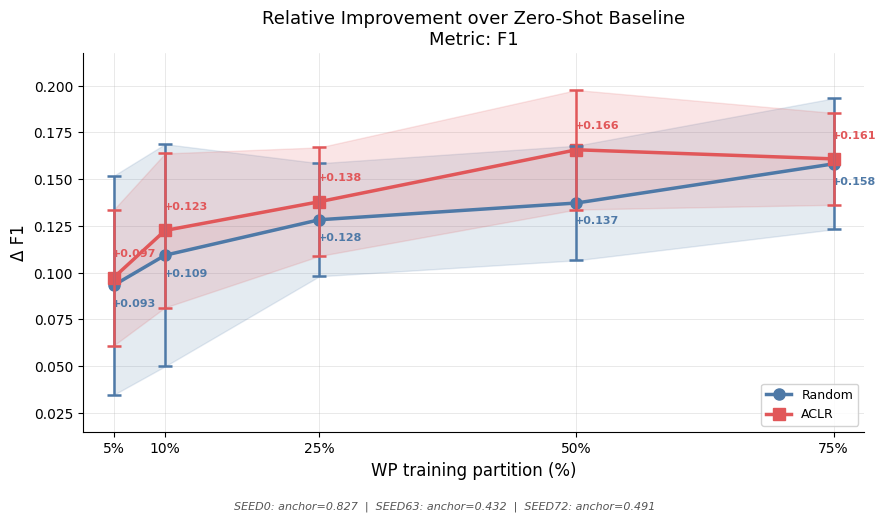

In [53]:
fig = plot_relative_improvement(
    df_seed0 = df_seed0_results,
    df_seed63 = df_seed63_results,
    df_seed72=df_seed72_results,
    df_baseline=df_baseline,
    metric='f1'
)

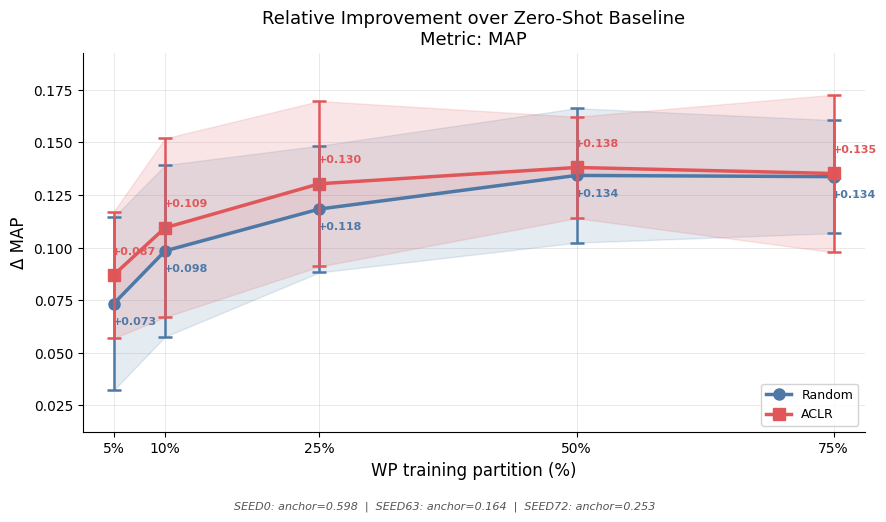

In [43]:
fig = plot_relative_improvement(
    df_seed0 = df_seed0_results,
    df_seed63 = df_seed63_results,
    df_seed72=df_seed72_results,
    df_baseline=df_baseline,
    metric='mAP'
)

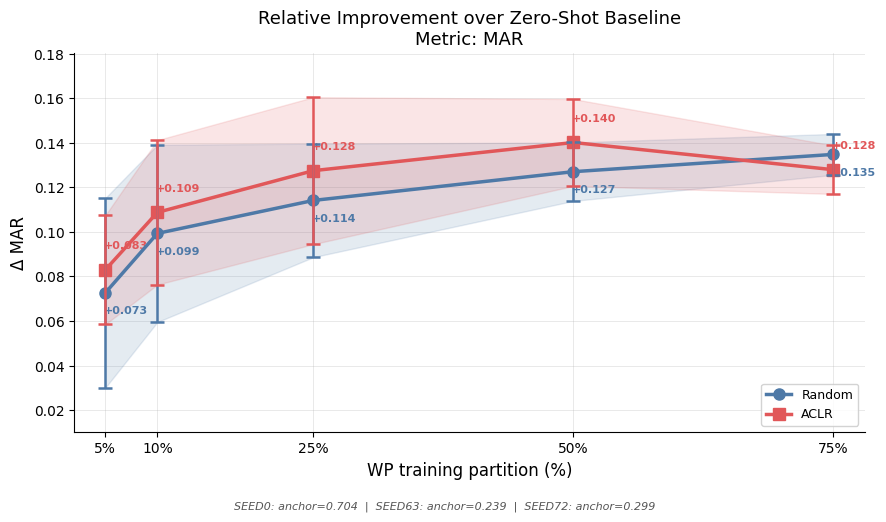

In [54]:
fig = plot_relative_improvement(
    df_seed0 = df_seed0_results,
    df_seed63 = df_seed63_results,
    df_seed72=df_seed72_results,
    df_baseline=df_baseline,
    metric='mAR'
)

## All seeds

In [ ]:
def _extract_vals(df: pd.DataFrame, method_prefix: str,
                  seed: int, partitions: list, metric: str) -> np.ndarray:
    """Return metric values for a given method/seed across partitions."""
    vals = []
    for p in partitions:
        if method_prefix == "random":
            key = f"p{p}_SEED{seed}_nms"
        else:
            key = f"ACLR_p{p}_SEED{seed}_nms"
        row = df[df["eval_key"] == key]
        vals.append(row.iloc[0][metric] if not row.empty else np.nan)
    return np.array(vals)

    
def plot_efficiency_curves(
    df_seed0:  pd.DataFrame,
    df_seed63: pd.DataFrame,
    df_seed72: pd.DataFrame,
    partitions: list = None,
    metrics: list = None,
    save_path: str = None,
):
    """
    3×3 grid figure:
        rows    = seeds  (SEED0, SEED63, SEED72)
        columns = metrics (mAP, mAR, F1)
 
    Each cell shows Random vs ACLR absolute performance across partition sizes
    for that specific seed × metric combination.
 
    Parameters
    ----------
    df_seed0/63/72 : DataFrames with eval_key, mAP, mAR, f1 columns
    partitions     : list of ints, default [5, 10, 25, 50, 75]
    metrics        : list of str, default ["mAP", "mAR", "f1"]
    save_path      : path stem (no extension); saves .png + .pdf if given
    """
    if partitions is None:
        partitions = [5, 10, 25, 50, 75]
    if metrics is None:
        metrics = ["mAP", "mAR", "f1"]
 
    seed_map    = [(0, df_seed0), (63, df_seed63), (72, df_seed72)]
    metric_labels = {"mAP": "mAP", "mAR": "mAR", "f1": "F1"}
 
    COLOR_RANDOM = "#4e79a7"
    COLOR_ACLR   = "#e15759"
    LW           = 2.5
    MARKERS      = {"random": "o", "aclr": "s"}
 
    fig, axes = plt.subplots(
        3, 3, figsize=(15, 12),
        sharey=False, sharex=True,
    )
    fig.suptitle(
        "Data Efficiency — Absolute Performance vs Partition Size\n"
        "Rows = Seeds  |  Columns = Metrics  |  Random vs ACLR",
        fontsize=14, fontweight="bold", y=1.01,
    )
 
    x = np.array(partitions)
 
    for row_idx, (seed, df) in enumerate(seed_map):
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            m_label = metric_labels.get(metric, metric.upper())
 
            r_vals = _extract_vals(df, "random", seed, partitions, metric)
            a_vals = _extract_vals(df, "aclr",   seed, partitions, metric)
 
            for vals, color, method in [
                (r_vals, COLOR_RANDOM, "random"),
                (a_vals, COLOR_ACLR,   "aclr"),
            ]:
                valid = ~np.isnan(vals)
                if not valid.any():
                    continue
                label = "Random" if method == "random" else "ACLR"
                ax.plot(x[valid], vals[valid],
                        color=color, linewidth=LW,
                        marker=MARKERS[method], markersize=7,
                        label=label, zorder=4)
 
                # value annotations
                for xi, v in zip(x[valid], vals[valid]):
                    offset = +10 if method == "random" else -14
                    ax.annotate(f"{v:.3f}", (xi, v),
                                textcoords="offset points",
                                xytext=(0, offset),
                                ha="center", fontsize=7,
                                color=color, fontweight="bold")
 
            # shade advantage region between the two lines
            valid_both = ~(np.isnan(r_vals) | np.isnan(a_vals))
            if valid_both.any():
                ax.fill_between(x[valid_both],
                                r_vals[valid_both], a_vals[valid_both],
                                where=a_vals[valid_both] >= r_vals[valid_both],
                                alpha=0.12, color=COLOR_ACLR)
                ax.fill_between(x[valid_both],
                                r_vals[valid_both], a_vals[valid_both],
                                where=r_vals[valid_both] > a_vals[valid_both],
                                alpha=0.12, color=COLOR_RANDOM)
 
            # ── formatting ────────────────────────────────────────────────
            ax.set_xlim(x[0] - 3, x[-1] + 3)
            all_v = np.concatenate([r_vals, a_vals])
            all_v = all_v[~np.isnan(all_v)]
            if len(all_v):
                pad = (all_v.max() - all_v.min()) * 0.15 + 0.02
                ax.set_ylim(all_v.min() - pad, all_v.max() + pad)
 
            ax.set_xticks(partitions)
            ax.grid(True, linewidth=0.4, alpha=0.5)
            ax.spines[["top", "right"]].set_visible(False)
 
            # column headers (top row only)
            if row_idx == 0:
                ax.set_title(m_label, fontsize=12, fontweight="bold", pad=8)
 
            # row labels (left column only)
            if col_idx == 0:
                ax.set_ylabel(f"SEED{seed}\n{m_label}", fontsize=10)
            else:
                ax.set_ylabel(m_label, fontsize=9)
 
            # x-axis labels (bottom row only)
            if row_idx == 2:
                ax.set_xticklabels([f"{p}%" for p in partitions], fontsize=9)
                ax.set_xlabel("WP training partition (%)", fontsize=10)
 
            # legend (top-left cell only)
            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=8.5, loc="lower right", framealpha=0.85)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{save_path}.pdf", dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}.png / .pdf")
    plt.show()
    return fig

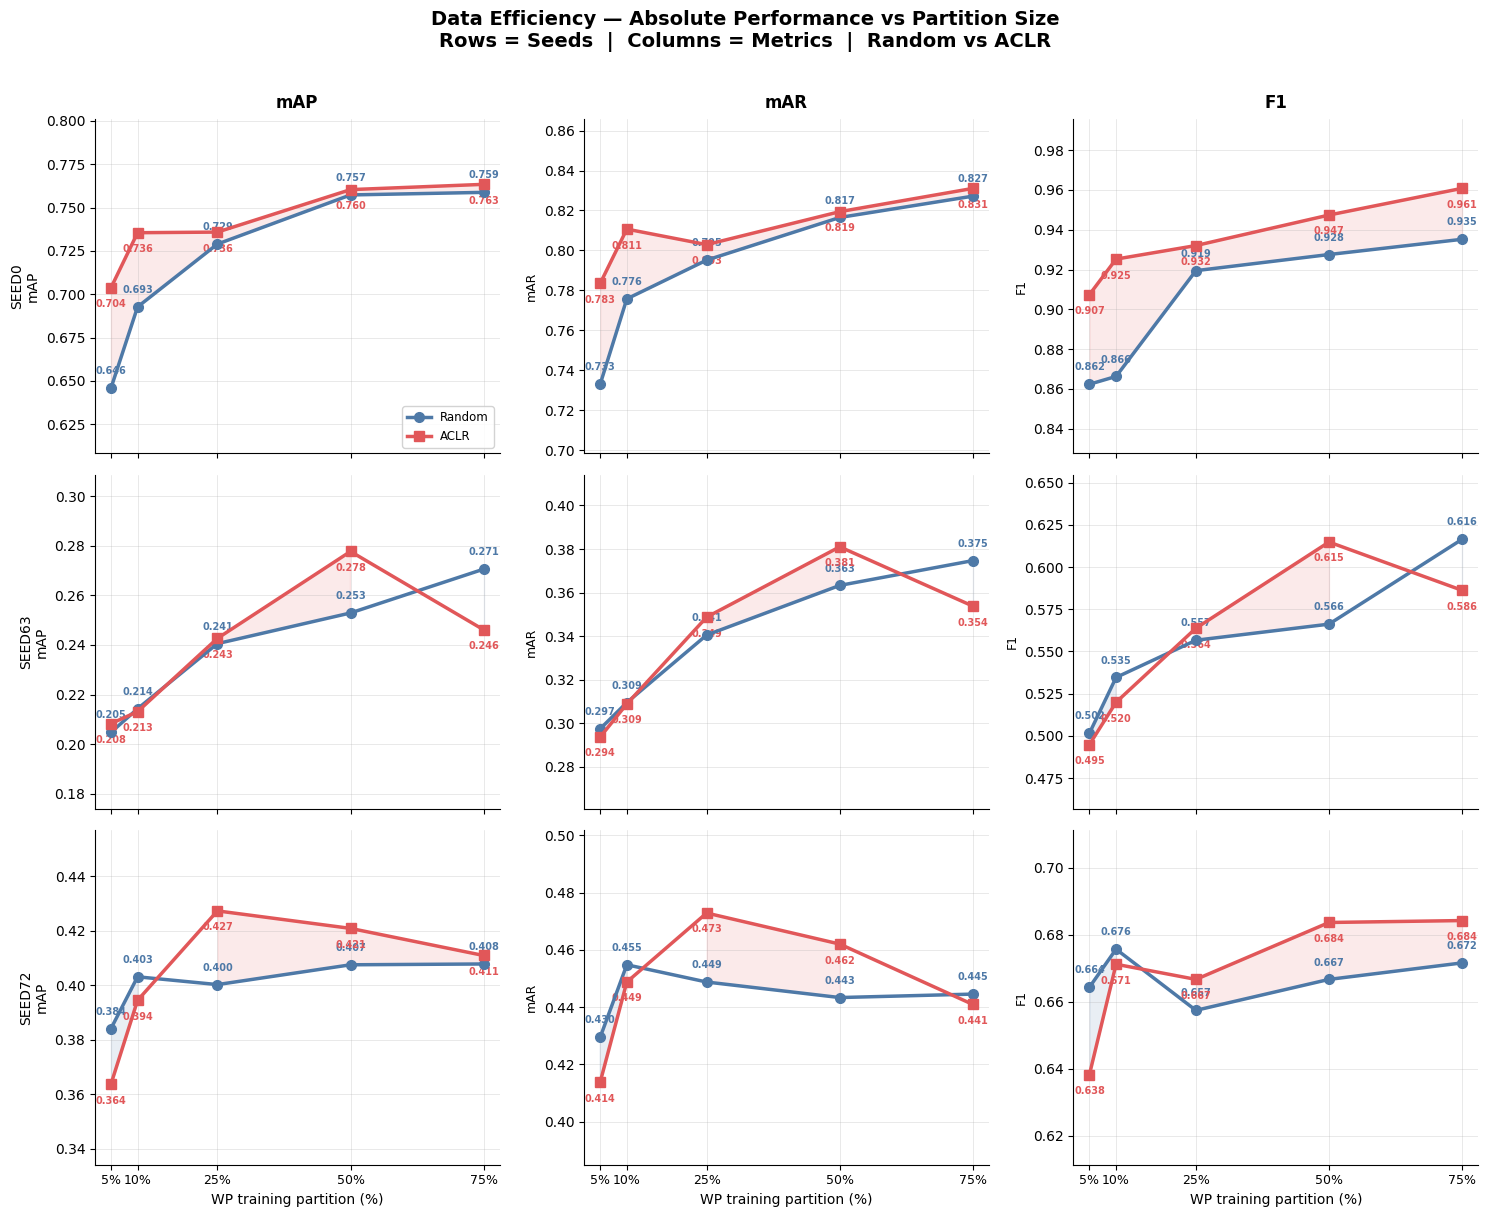

In [55]:
fig = plot_efficiency_curves(
        df_seed0_results, df_seed63_results, df_seed72_results,
        partitions=[5, 10, 25, 50, 75],
        metrics=["mAP", "mAR", "f1"],
    )